# Quantitative Statistics for Image-Schema LLM Thesis

This notebook generates thesis-ready quantitative statistics from the project outputs.

Run it from the project `notebooks/` directory. It expects:

```text
data/gold/sentences_v1.jsonl
data/outputs/parsed_responses.jsonl
data/outputs/raw_responses.jsonl
```

Outputs are written to:

```text
data/outputs/quantitative_statistics/
```

Analyses produced:

1. Gold dataset distribution.
2. Run and parser coverage.
3. Prompt-level headline metrics.
4. Provider/model metrics.
5. Sentence-type metrics.
6. Schema-family metrics.
7. Precision, recall, F1, and macro-F1.
8. Confusion matrices.
9. Abstention and over-attribution metrics.
10. v1/v2 paired comparison.
11. Temperature/condition stability.
12. Provider agreement and conservatism.
13. Thesis-ready summary tables.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.metrics import classification_report
    SKLEARN_AVAILABLE = True
except Exception as exc:
    print("scikit-learn unavailable; using fallback metrics where possible:", exc)
    SKLEARN_AVAILABLE = False

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
GOLD_PATH = DATA_DIR / "gold" / "sentences_v1.jsonl"
OUTPUTS_DIR = DATA_DIR / "outputs"
PARSED_PATH = OUTPUTS_DIR / "parsed_responses.jsonl"
RAW_PATH = OUTPUTS_DIR / "raw_responses.jsonl"

EXPORT_DIR = OUTPUTS_DIR / "quantitative_statistics"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("EXPORT_DIR:", EXPORT_DIR)

def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            if line.strip():
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} line {i}: {exc}") from exc
    return pd.DataFrame(rows)

def save_csv(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    path = EXPORT_DIR / filename
    df.to_csv(path, index=index)
    print(f"Wrote {path}")
    return path

def pct(x, digits: int = 1) -> str:
    if pd.isna(x):
        return ""
    return f"{100*x:.{digits}f}%"

def wilson_ci(successes: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    phat = successes / n
    denom = 1 + z*z/n
    centre = (phat + z*z/(2*n)) / denom
    half = z * math.sqrt((phat*(1-phat) + z*z/(4*n)) / n) / denom
    return centre - half, centre + half

def add_wilson_columns(df: pd.DataFrame, success_col: str, n_col: str, prefix: str) -> pd.DataFrame:
    out = df.copy()
    lows, highs = [], []
    for _, row in out.iterrows():
        low, high = wilson_ci(int(row[success_col]), int(row[n_col]))
        lows.append(low)
        highs.append(high)
    out[f"{prefix}_ci_low"] = lows
    out[f"{prefix}_ci_high"] = highs
    return out

def prompt_base(prompt_id: Any) -> str:
    p = str(prompt_id)
    if "direct_schema" in p:
        return "direct_schema"
    if "structured_roles" in p:
        return "structured_roles"
    if "naive" in p:
        return "naive"
    return "other"

def prompt_generation(prompt_id: Any) -> str:
    p = str(prompt_id)
    if "v2" in p or "abstention" in p:
        return "v2_abstention"
    if "v1" in p:
        return "v1"
    return "unknown"

def condition_short(condition_id: Any) -> str:
    c = str(condition_id)
    if "temp_03" in c:
        return "temp_03"
    if "temp_07" in c:
        return "temp_07"
    if "temp_0" in c:
        return "temp_0"
    return c

gold = read_jsonl(GOLD_PATH)
parsed_all = read_jsonl(PARSED_PATH)
raw = read_jsonl(RAW_PATH) if RAW_PATH.exists() else pd.DataFrame()

print("Gold records:", len(gold))
print("Parsed records:", len(parsed_all))
print("Raw records:", len(raw))

scikit-learn unavailable; using fallback metrics where possible: No module named 'sklearn'
PROJECT_ROOT: /Users/Shared/image_schema_llm_project
EXPORT_DIR: /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics
Gold records: 200
Parsed records: 9000
Raw records: 9000


## 1. Normalise and derive analysis columns

In [2]:
df = parsed_all.copy()

df["prompt_base"] = df["prompt_id"].map(prompt_base)
df["prompt_generation"] = df["prompt_id"].map(prompt_generation)
df["condition_short"] = df["condition_id"].map(condition_short)

df["is_structured"] = df["parse_status"].eq("parsed")
df["is_control"] = df["sentence_type"].eq("control_weak_schema")
df["is_non_control"] = ~df["is_control"]

if "schema_present" not in df.columns:
    df["schema_present"] = np.where(df["main_image_schema"].eq("NONE"), "no", "yes")

df["predicted_schema_present_bool"] = (
    df["schema_present"].astype(str).str.lower().eq("yes")
    | (~df["main_image_schema"].astype(str).eq("NONE") & df["main_image_schema"].notna())
)
df["gold_schema_present_bool"] = ~df["is_control"]

df["schema_present_correct"] = df["predicted_schema_present_bool"].eq(df["gold_schema_present_bool"])
df["primary_schema_correct"] = df["main_image_schema"].eq(df["expected_schema_primary"])
df["lm_correct"] = df["literal_or_metaphorical"].eq(df["expected_literal_or_metaphorical"])

df["control_correct"] = (
    df["is_control"]
    & df["main_image_schema"].eq("NONE")
    & df["literal_or_metaphorical"].eq("control")
)

df["control_false_positive_schema"] = (
    df["is_control"]
    & df["main_image_schema"].notna()
    & ~df["main_image_schema"].eq("NONE")
)

df["non_control_over_abstention"] = (
    df["is_non_control"]
    & (
        df["main_image_schema"].eq("NONE")
        | df["literal_or_metaphorical"].eq("control")
        | df["schema_present"].astype(str).str.lower().eq("no")
    )
)

structured = df[df["is_structured"]].copy()
naive = df[~df["is_structured"]].copy()

print("Structured:", len(structured))
print("Naive/free text:", len(naive))
display(structured.head())

Structured: 7200
Naive/free text: 1800


,run_key,run_index,provider,model_id,model_name,prompt_id,prompt_family,prompt_version,condition_id,condition_family,...,is_control,is_non_control,predicted_schema_present_bool,gold_schema_present_bool,schema_present_correct,primary_schema_correct,lm_correct,control_correct,control_false_positive_schema,non_control_over_abstention
620,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,600,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,True,True,True,True,True,True,False,False,False
621,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,601,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,True,True,True,True,True,True,False,False,False
622,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,602,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,True,True,True,True,True,True,False,False,False
623,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,603,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,True,True,True,True,True,True,False,False,False
624,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,604,openai,openai_gpt_5_4_mini,gpt-5.4-mini,p_direct_schema_v1,direct_schema,v1.0,c_temp_0_v1,deterministic,...,False,True,True,True,True,False,True,False,False,False


## 2. Gold dataset distribution

In [3]:
gold_summary = pd.DataFrame({
    "metric": [
        "total_sentences",
        "literal_spatial",
        "metaphorical_spatial",
        "control_weak_schema",
    ],
    "count": [
        len(gold),
        int((gold["sentence_type"] == "literal_spatial").sum()),
        int((gold["sentence_type"] == "metaphorical_spatial").sum()),
        int((gold["sentence_type"] == "control_weak_schema").sum()),
    ]
})
save_csv(gold_summary, "gold_dataset_sentence_type_summary.csv")
display(gold_summary)

gold_schema_counts = (
    gold.groupby("expected_schema_primary")
    .size()
    .reset_index(name="count")
    .sort_values(["expected_schema_primary"])
)
save_csv(gold_schema_counts, "gold_dataset_schema_counts.csv")
display(gold_schema_counts)

gold_type_schema = pd.crosstab(gold["sentence_type"], gold["expected_schema_primary"])
save_csv(gold_type_schema.reset_index(), "gold_dataset_sentence_type_by_schema.csv")
display(gold_type_schema)

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/gold_dataset_sentence_type_summary.csv


,metric,count
0,total_sentences,200
1,literal_spatial,67
2,metaphorical_spatial,67
3,control_weak_schema,66


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/gold_dataset_schema_counts.csv


,expected_schema_primary,count
0,BLOCKAGE,22
1,CONTAINER,23
2,FORCE,22
3,NONE,66
4,SOURCE_PATH_GOAL,23
5,SUPPORT_BALANCE,22
6,VERTICALITY,22


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/gold_dataset_sentence_type_by_schema.csv


expected_schema_primary,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
sentence_type,,,,,,,
control_weak_schema,0,0,0,66,0,0,0
literal_spatial,11,12,11,0,11,11,11
metaphorical_spatial,11,11,11,0,12,11,11


## 3. Run, parse, and coverage statistics

In [4]:
parse_counts = (
    df.groupby(["parse_status"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
save_csv(parse_counts, "parse_status_counts.csv")
display(parse_counts)

if "parser_strategy" in df.columns:
    strategy_counts = (
        df.groupby("parser_strategy")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    save_csv(strategy_counts, "parser_strategy_counts.csv")
    display(strategy_counts)

if "parse_quality" in df.columns:
    quality_counts = (
        df.groupby("parse_quality")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    save_csv(quality_counts, "parse_quality_counts.csv")
    display(quality_counts)

coverage = pd.DataFrame([
    {"metric": "raw_records", "count": len(raw) if not raw.empty else np.nan},
    {"metric": "parsed_records_all", "count": len(df)},
    {"metric": "structured_usable_records", "count": len(structured)},
    {"metric": "naive_free_text_records", "count": len(naive)},
    {"metric": "unique_sentences_in_structured", "count": structured["sentence_id"].nunique()},
    {"metric": "unique_models_in_structured", "count": structured["model_id"].nunique()},
    {"metric": "unique_prompts_in_structured", "count": structured["prompt_id"].nunique()},
    {"metric": "unique_conditions_in_structured", "count": structured["condition_id"].nunique()},
])
save_csv(coverage, "run_coverage_summary.csv")
display(coverage)

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/parse_status_counts.csv


,parse_status,count
1,parsed,7200
0,free_text_unparsed,1800


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/parser_strategy_counts.csv


,parser_strategy,count
3,strict_json,5881
1,free_text,1800
0,fenced_json,1200
2,partial_field_recovery,119


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/parse_quality_counts.csv


,parse_quality,count
0,complete,7081
1,free_text,1800
2,partial_core_fields,119


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/run_coverage_summary.csv


,metric,count
0,raw_records,9000
1,parsed_records_all,9000
2,structured_usable_records,7200
3,naive_free_text_records,1800
4,unique_sentences_in_structured,200
5,unique_models_in_structured,3
6,unique_prompts_in_structured,4
7,unique_conditions_in_structured,2


## 4. Headline metrics

In [5]:
def metrics_for_group(g: pd.DataFrame) -> dict:
    controls = g[g["is_control"]]
    non_controls = g[g["is_non_control"]]
    return {
        "n": len(g),
        "control_n": len(controls),
        "non_control_n": len(non_controls),
        "primary_schema_accuracy": g["primary_schema_correct"].mean(),
        "lm_accuracy": g["lm_correct"].mean(),
        "schema_present_accuracy": g["schema_present_correct"].mean(),
        "control_accuracy": controls["control_correct"].mean() if len(controls) else np.nan,
        "control_false_positive_schema_rate": controls["control_false_positive_schema"].mean() if len(controls) else np.nan,
        "non_control_lm_accuracy": non_controls["lm_correct"].mean() if len(non_controls) else np.nan,
        "non_control_primary_schema_accuracy": non_controls["primary_schema_correct"].mean() if len(non_controls) else np.nan,
        "non_control_over_abstention_rate": non_controls["non_control_over_abstention"].mean() if len(non_controls) else np.nan,
    }

def group_metrics(data: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows = []
    for keys, g in data.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(metrics_for_group(g))
        rows.append(row)
    return pd.DataFrame(rows)

overall_metrics = pd.DataFrame([metrics_for_group(structured)])
save_csv(overall_metrics, "headline_overall_metrics.csv")
display(overall_metrics)

prompt_metrics = group_metrics(structured, ["prompt_id", "prompt_base", "prompt_generation"]).sort_values("prompt_id")
save_csv(prompt_metrics, "headline_prompt_metrics.csv")
display(prompt_metrics)

provider_metrics = group_metrics(structured, ["provider", "model_id"]).sort_values("provider")
save_csv(provider_metrics, "headline_provider_metrics.csv")
display(provider_metrics)

provider_prompt_metrics = group_metrics(structured, ["provider", "model_id", "prompt_id"]).sort_values(["provider", "prompt_id"])
save_csv(provider_prompt_metrics, "headline_provider_prompt_metrics.csv")
display(provider_prompt_metrics)

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/headline_overall_metrics.csv


,n,control_n,non_control_n,primary_schema_accuracy,lm_accuracy,schema_present_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy,non_control_primary_schema_accuracy,non_control_over_abstention_rate
0,7200,2376,4824,0.80625,0.891111,0.8925,0.678451,0.321549,0.995854,0.869196,0.002073


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/headline_prompt_metrics.csv


,prompt_id,prompt_base,prompt_generation,n,control_n,non_control_n,primary_schema_accuracy,lm_accuracy,schema_present_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy,non_control_primary_schema_accuracy,non_control_over_abstention_rate
0,p_direct_schema_v1,direct_schema,v1,1800,594,1206,0.719444,0.807778,0.808333,0.419192,0.580808,0.999171,0.867330,0.000000
1,p_direct_schema_v2_abstention,direct_schema,v2_abstention,1800,594,1206,0.859444,0.927222,0.927222,0.784512,0.215488,0.997512,0.896352,0.002488
2,p_structured_roles_v1,structured_roles,v1,1800,594,1206,0.803333,0.905000,0.906667,0.727273,0.272727,0.992537,0.840796,0.004975
3,p_structured_roles_v2_abstention,structured_roles,v2_abstention,1800,594,1206,0.842778,0.924444,0.927778,0.782828,0.217172,0.994196,0.872305,0.000829


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/headline_provider_metrics.csv


,provider,model_id,n,control_n,non_control_n,primary_schema_accuracy,lm_accuracy,schema_present_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy,non_control_primary_schema_accuracy,non_control_over_abstention_rate
0,anthropic,claude_sonnet_4_6,2400,792,1608,0.772083,0.855417,0.856667,0.565657,0.434343,0.998134,0.873756,0.000000
1,google,gemini_2_5_flash,2400,792,1608,0.761667,0.837917,0.837917,0.508838,0.491162,1.000000,0.886194,0.000000
2,openai,openai_gpt_5_4_mini,2400,792,1608,0.885000,0.980000,0.982917,0.960859,0.039141,0.989428,0.847637,0.006219


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/headline_provider_prompt_metrics.csv


,provider,model_id,prompt_id,n,control_n,non_control_n,primary_schema_accuracy,lm_accuracy,schema_present_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy,non_control_primary_schema_accuracy,non_control_over_abstention_rate
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,600,198,402,0.610000,0.685000,0.685000,0.045455,0.954545,1.000000,0.888060,0.000000
1,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,600,198,402,0.858333,0.921667,0.921667,0.762626,0.237374,1.000000,0.905473,0.000000
2,anthropic,claude_sonnet_4_6,p_structured_roles_v1,600,198,402,0.806667,0.911667,0.911667,0.732323,0.267677,1.000000,0.843284,0.000000
3,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,600,198,402,0.813333,0.903333,0.908333,0.722222,0.277778,0.992537,0.858209,0.000000
4,google,gemini_2_5_flash,p_direct_schema_v1,600,198,402,0.705000,0.768333,0.768333,0.297980,0.702020,1.000000,0.905473,0.000000
5,google,gemini_2_5_flash,p_direct_schema_v2_abstention,600,198,402,0.811667,0.871667,0.871667,0.611111,0.388889,1.000000,0.910448,0.000000
6,google,gemini_2_5_flash,p_structured_roles_v1,600,198,402,0.728333,0.826667,0.826667,0.474747,0.525253,1.000000,0.853234,0.000000
7,google,gemini_2_5_flash,p_structured_roles_v2_abstention,600,198,402,0.801667,0.885000,0.885000,0.651515,0.348485,1.000000,0.875622,0.000000
8,openai,openai_gpt_5_4_mini,p_direct_schema_v1,600,198,402,0.843333,0.970000,0.971667,0.914141,0.085859,0.997512,0.808458,0.000000
9,openai,openai_gpt_5_4_mini,p_direct_schema_v2_abstention,600,198,402,0.908333,0.988333,0.988333,0.979798,0.020202,0.992537,0.873134,0.007463


## 5. Sentence-type and schema-family metrics

In [6]:
sentence_type_metrics = group_metrics(structured, ["prompt_id", "sentence_type"]).sort_values(["prompt_id", "sentence_type"])
save_csv(sentence_type_metrics, "sentence_type_metrics_by_prompt.csv")
display(sentence_type_metrics)

schema_family_metrics = group_metrics(structured, ["expected_schema_primary", "prompt_generation"]).sort_values(["expected_schema_primary", "prompt_generation"])
save_csv(schema_family_metrics, "schema_family_metrics_by_generation.csv")
display(schema_family_metrics)

schema_prompt_metrics = group_metrics(structured, ["expected_schema_primary", "prompt_id"]).sort_values(["expected_schema_primary", "prompt_id"])
save_csv(schema_prompt_metrics, "schema_family_metrics_by_prompt.csv")
display(schema_prompt_metrics)

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/sentence_type_metrics_by_prompt.csv


,prompt_id,sentence_type,n,control_n,non_control_n,primary_schema_accuracy,lm_accuracy,schema_present_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy,non_control_primary_schema_accuracy,non_control_over_abstention_rate
0,p_direct_schema_v1,control_weak_schema,594,594,0,0.419192,0.419192,0.419192,0.419192,0.580808,NaN,NaN,NaN
1,p_direct_schema_v1,literal_spatial,603,0,603,0.829187,0.998342,1.000000,NaN,NaN,0.998342,0.829187,0.000000
2,p_direct_schema_v1,metaphorical_spatial,603,0,603,0.905473,1.000000,1.000000,NaN,NaN,1.000000,0.905473,0.000000
3,p_direct_schema_v2_abstention,control_weak_schema,594,594,0,0.784512,0.784512,0.784512,0.784512,0.215488,NaN,NaN,NaN
4,p_direct_schema_v2_abstention,literal_spatial,603,0,603,0.864013,1.000000,1.000000,NaN,NaN,1.000000,0.864013,0.000000
5,p_direct_schema_v2_abstention,metaphorical_spatial,603,0,603,0.928690,0.995025,0.995025,NaN,NaN,0.995025,0.928690,0.004975
6,p_structured_roles_v1,control_weak_schema,594,594,0,0.727273,0.727273,0.727273,0.727273,0.272727,NaN,NaN,NaN
7,p_structured_roles_v1,literal_spatial,603,0,603,0.779436,0.985075,0.990050,NaN,NaN,0.985075,0.779436,0.009950
8,p_structured_roles_v1,metaphorical_spatial,603,0,603,0.902156,1.000000,1.000000,NaN,NaN,1.000000,0.902156,0.000000
9,p_structured_roles_v2_abstention,control_weak_schema,594,594,0,0.782828,0.782828,0.782828,0.782828,0.217172,NaN,NaN,NaN


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/schema_family_metrics_by_generation.csv


,expected_schema_primary,prompt_generation,n,control_n,non_control_n,primary_schema_accuracy,lm_accuracy,schema_present_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy,non_control_primary_schema_accuracy,non_control_over_abstention_rate
0,BLOCKAGE,v1,396,0,396,0.959596,0.989899,0.992424,NaN,NaN,0.989899,0.959596,0.007576
1,BLOCKAGE,v2_abstention,396,0,396,0.982323,0.984848,1.000000,NaN,NaN,0.984848,0.982323,0.000000
2,CONTAINER,v1,414,0,414,0.845411,1.000000,1.000000,NaN,NaN,1.000000,0.845411,0.000000
3,CONTAINER,v2_abstention,414,0,414,0.876812,1.000000,1.000000,NaN,NaN,1.000000,0.876812,0.000000
4,FORCE,v1,396,0,396,0.848485,1.000000,1.000000,NaN,NaN,1.000000,0.848485,0.000000
5,FORCE,v2_abstention,396,0,396,0.881313,1.000000,1.000000,NaN,NaN,1.000000,0.881313,0.000000
6,NONE,v1,1188,1188,0,0.573232,0.573232,0.573232,0.573232,0.426768,NaN,NaN,NaN
7,NONE,v2_abstention,1188,1188,0,0.783670,0.783670,0.783670,0.783670,0.216330,NaN,NaN,NaN
8,SOURCE_PATH_GOAL,v1,414,0,414,0.995169,1.000000,1.000000,NaN,NaN,1.000000,0.995169,0.000000
9,SOURCE_PATH_GOAL,v2_abstention,414,0,414,0.983092,0.990338,0.990338,NaN,NaN,0.990338,0.983092,0.009662


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/schema_family_metrics_by_prompt.csv


,expected_schema_primary,prompt_id,n,control_n,non_control_n,primary_schema_accuracy,lm_accuracy,schema_present_accuracy,control_accuracy,control_false_positive_schema_rate,non_control_lm_accuracy,non_control_primary_schema_accuracy,non_control_over_abstention_rate
0,BLOCKAGE,p_direct_schema_v1,198,0,198,0.964646,0.994949,1.000000,NaN,NaN,0.994949,0.964646,0.000000
1,BLOCKAGE,p_direct_schema_v2_abstention,198,0,198,0.974747,1.000000,1.000000,NaN,NaN,1.000000,0.974747,0.000000
2,BLOCKAGE,p_structured_roles_v1,198,0,198,0.954545,0.984848,0.984848,NaN,NaN,0.984848,0.954545,0.015152
3,BLOCKAGE,p_structured_roles_v2_abstention,198,0,198,0.989899,0.969697,1.000000,NaN,NaN,0.969697,0.989899,0.000000
4,CONTAINER,p_direct_schema_v1,207,0,207,0.917874,1.000000,1.000000,NaN,NaN,1.000000,0.917874,0.000000
5,CONTAINER,p_direct_schema_v2_abstention,207,0,207,0.898551,1.000000,1.000000,NaN,NaN,1.000000,0.898551,0.000000
6,CONTAINER,p_structured_roles_v1,207,0,207,0.772947,1.000000,1.000000,NaN,NaN,1.000000,0.772947,0.000000
7,CONTAINER,p_structured_roles_v2_abstention,207,0,207,0.855072,1.000000,1.000000,NaN,NaN,1.000000,0.855072,0.000000
8,FORCE,p_direct_schema_v1,198,0,198,0.853535,1.000000,1.000000,NaN,NaN,1.000000,0.853535,0.000000
9,FORCE,p_direct_schema_v2_abstention,198,0,198,0.878788,1.000000,1.000000,NaN,NaN,1.000000,0.878788,0.000000


## 6. Precision, recall, F1, and macro-F1

In [7]:
def classification_report_df(data: pd.DataFrame, gold_col: str, pred_col: str, group_cols: list[str] | None = None, target_name: str = "schema") -> pd.DataFrame:
    rows = []
    iterator = data.groupby(group_cols, dropna=False) if group_cols else [("ALL", data)]
    for keys, g in iterator:
        if not isinstance(keys, tuple):
            keys = (keys,)
        g = g[[gold_col, pred_col]].dropna()
        if g.empty:
            continue

        if SKLEARN_AVAILABLE:
            report = classification_report(
                g[gold_col].astype(str),
                g[pred_col].astype(str),
                output_dict=True,
                zero_division=0,
            )
            for class_label, vals in report.items():
                if isinstance(vals, dict):
                    row = {col: key for col, key in zip(group_cols or ["group"], keys)}
                    row.update({
                        "target": target_name,
                        "class_label": class_label,
                        "precision": vals.get("precision"),
                        "recall": vals.get("recall"),
                        "f1_score": vals.get("f1-score"),
                        "support": vals.get("support"),
                    })
                    rows.append(row)
        else:
            labels = sorted(set(g[gold_col].astype(str)) | set(g[pred_col].astype(str)))
            for lab in labels:
                y_true = g[gold_col].astype(str).eq(lab)
                y_pred = g[pred_col].astype(str).eq(lab)
                tp = int((y_true & y_pred).sum())
                fp = int((~y_true & y_pred).sum())
                fn = int((y_true & ~y_pred).sum())
                precision = tp / (tp + fp) if (tp + fp) else 0.0
                recall = tp / (tp + fn) if (tp + fn) else 0.0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
                row = {col: key for col, key in zip(group_cols or ["group"], keys)}
                row.update({"target": target_name, "class_label": lab, "precision": precision, "recall": recall, "f1_score": f1, "support": int(y_true.sum())})
                rows.append(row)
    return pd.DataFrame(rows)

schema_report_by_prompt = classification_report_df(
    structured, "expected_schema_primary", "main_image_schema",
    group_cols=["prompt_id"], target_name="primary_schema"
)
save_csv(schema_report_by_prompt, "classification_report_schema_by_prompt.csv")
display(schema_report_by_prompt.head(40))

lm_report_by_prompt = classification_report_df(
    structured, "expected_literal_or_metaphorical", "literal_or_metaphorical",
    group_cols=["prompt_id"], target_name="literal_metaphorical"
)
save_csv(lm_report_by_prompt, "classification_report_lm_by_prompt.csv")
display(lm_report_by_prompt.head(40))

schema_report_by_provider = classification_report_df(
    structured, "expected_schema_primary", "main_image_schema",
    group_cols=["provider", "model_id"], target_name="primary_schema"
)
save_csv(schema_report_by_provider, "classification_report_schema_by_provider.csv")
display(schema_report_by_provider.head(40))

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/classification_report_schema_by_prompt.csv


,prompt_id,target,class_label,precision,recall,f1_score,support
0,p_direct_schema_v1,primary_schema,BLOCKAGE,0.969543,0.964646,0.967089,198
1,p_direct_schema_v1,primary_schema,CONTAINER,0.539773,0.917874,0.679785,207
2,p_direct_schema_v1,primary_schema,FORCE,0.684211,0.853535,0.759551,198
3,p_direct_schema_v1,primary_schema,NONE,1.000000,0.419192,0.590747,594
4,p_direct_schema_v1,primary_schema,SOURCE_PATH_GOAL,0.473441,0.990338,0.640625,207
5,p_direct_schema_v1,primary_schema,SUPPORT_BALANCE,0.934132,0.787879,0.854795,198
6,p_direct_schema_v1,primary_schema,VERTICALITY,0.870968,0.681818,0.764873,198
7,p_direct_schema_v2_abstention,primary_schema,BLOCKAGE,0.960199,0.974747,0.967419,198
8,p_direct_schema_v2_abstention,primary_schema,CONTAINER,0.723735,0.898551,0.801724,207
9,p_direct_schema_v2_abstention,primary_schema,FORCE,0.787330,0.878788,0.830549,198


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/classification_report_lm_by_prompt.csv


,prompt_id,target,class_label,precision,recall,f1_score,support
0,p_direct_schema_v1,literal_metaphorical,control,1.000000,0.419192,0.590747,594
1,p_direct_schema_v1,literal_metaphorical,literal,0.680226,0.998342,0.809140,603
2,p_direct_schema_v1,literal_metaphorical,metaphorical,0.905405,1.000000,0.950355,603
3,p_direct_schema_v2_abstention,literal_metaphorical,control,0.993603,0.784512,0.876764,594
4,p_direct_schema_v2_abstention,literal_metaphorical,literal,0.882870,1.000000,0.937792,603
5,p_direct_schema_v2_abstention,literal_metaphorical,metaphorical,0.958466,0.995025,0.976404,603
6,p_direct_schema_v2_abstention,literal_metaphorical,uncertain,0.000000,0.000000,0.000000,0
7,p_structured_roles_v1,literal_metaphorical,control,0.986301,0.727273,0.837209,594
8,p_structured_roles_v1,literal_metaphorical,literal,0.889222,0.985075,0.934697,603
9,p_structured_roles_v1,literal_metaphorical,metaphorical,0.868876,1.000000,0.929838,603


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/classification_report_schema_by_provider.csv


,provider,model_id,target,class_label,precision,recall,f1_score,support
0,anthropic,claude_sonnet_4_6,primary_schema,BLOCKAGE,0.956522,1.000000,0.977778,264
1,anthropic,claude_sonnet_4_6,primary_schema,CONTAINER,0.641910,0.876812,0.741194,276
2,anthropic,claude_sonnet_4_6,primary_schema,FORCE,0.702381,0.893939,0.786667,264
3,anthropic,claude_sonnet_4_6,primary_schema,NONE,1.000000,0.565657,0.722581,792
4,anthropic,claude_sonnet_4_6,primary_schema,SOURCE_PATH_GOAL,0.510166,1.000000,0.675643,276
5,anthropic,claude_sonnet_4_6,primary_schema,SUPPORT_BALANCE,0.947368,0.818182,0.878049,264
6,anthropic,claude_sonnet_4_6,primary_schema,VERTICALITY,0.881443,0.647727,0.746725,264
7,google,gemini_2_5_flash,primary_schema,BLOCKAGE,0.945652,0.988636,0.966667,264
8,google,gemini_2_5_flash,primary_schema,CONTAINER,0.557110,0.865942,0.678014,276
9,google,gemini_2_5_flash,primary_schema,FORCE,0.697885,0.875000,0.776471,264


## 7. Confusion matrices

In [8]:
def export_confusion(data: pd.DataFrame, gold_col: str, pred_col: str, filename_prefix: str, group_cols: list[str] | None = None):
    iterator = data.groupby(group_cols, dropna=False) if group_cols else [("ALL", data)]
    matrices = {}
    for keys, g in iterator:
        if not isinstance(keys, tuple):
            keys = (keys,)
        tab = pd.crosstab(g[gold_col].astype(str), g[pred_col].astype(str), rownames=["gold"], colnames=["predicted"], dropna=False)
        key_name = "__".join(str(k).replace("/", "_").replace(" ", "_") for k in keys)
        path = EXPORT_DIR / f"{filename_prefix}_{key_name}.csv"
        tab.to_csv(path)
        matrices[key_name] = tab
        print(f"Wrote {path}")
    return matrices

schema_conf_by_generation = export_confusion(
    structured, "expected_schema_primary", "main_image_schema",
    "confusion_schema_by_generation", group_cols=["prompt_generation"]
)

schema_conf_by_prompt = export_confusion(
    structured, "expected_schema_primary", "main_image_schema",
    "confusion_schema_by_prompt", group_cols=["prompt_id"]
)

lm_conf_by_prompt = export_confusion(
    structured, "expected_literal_or_metaphorical", "literal_or_metaphorical",
    "confusion_lm_by_prompt", group_cols=["prompt_id"]
)

for name, matrix in schema_conf_by_generation.items():
    print("\n", name)
    display(matrix)

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/confusion_schema_by_generation_v1.csv
Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/confusion_schema_by_generation_v2_abstention.csv
Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/confusion_schema_by_prompt_p_direct_schema_v1.csv
Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/confusion_schema_by_prompt_p_direct_schema_v2_abstention.csv
Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/confusion_schema_by_prompt_p_structured_roles_v1.csv
Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/confusion_schema_by_prompt_p_structured_roles_v2_abstention.csv
Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/confusion_lm_by_prompt_p_direct_schema_v1.csv
Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantit

predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,380,0,13,3,0,0,0
CONTAINER,0,350,0,0,63,0,1
FORCE,0,0,336,0,50,0,10
NONE,13,215,73,681,190,2,14
SOURCE_PATH_GOAL,0,2,0,0,412,0,0
SUPPORT_BALANCE,0,2,60,3,0,324,7
VERTICALITY,0,1,2,0,117,18,258



 v2_abstention


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,389,0,7,0,0,0,0
CONTAINER,2,363,0,0,45,0,4
FORCE,0,0,349,0,36,0,11
NONE,12,124,61,931,46,0,14
SOURCE_PATH_GOAL,0,3,0,4,407,0,0
SUPPORT_BALANCE,0,0,43,0,2,350,1
VERTICALITY,0,0,1,0,102,18,275


## 8. Abstention and over-attribution statistics

In [9]:
control = structured[structured["is_control"]].copy()
non_control = structured[structured["is_non_control"]].copy()

control_stats = (
    control.groupby(["prompt_id", "provider"])
    .agg(
        n=("run_key", "count"),
        control_correct_n=("control_correct", "sum"),
        control_false_positive_n=("control_false_positive_schema", "sum"),
        control_accuracy=("control_correct", "mean"),
        control_false_positive_rate=("control_false_positive_schema", "mean"),
    )
    .reset_index()
    .sort_values(["prompt_id", "provider"])
)
control_stats = add_wilson_columns(control_stats, "control_correct_n", "n", "control_accuracy")
control_stats = add_wilson_columns(control_stats, "control_false_positive_n", "n", "control_false_positive_rate")
save_csv(control_stats, "control_abstention_metrics_by_prompt_provider.csv")
display(control_stats)

over_abstention_stats = (
    non_control.groupby(["prompt_id", "provider"])
    .agg(
        n=("run_key", "count"),
        over_abstention_n=("non_control_over_abstention", "sum"),
        over_abstention_rate=("non_control_over_abstention", "mean"),
        primary_schema_accuracy=("primary_schema_correct", "mean"),
        lm_accuracy=("lm_correct", "mean"),
    )
    .reset_index()
    .sort_values(["prompt_id", "provider"])
)
save_csv(over_abstention_stats, "non_control_over_abstention_by_prompt_provider.csv")
display(over_abstention_stats)

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/control_abstention_metrics_by_prompt_provider.csv


,prompt_id,provider,n,control_correct_n,control_false_positive_n,control_accuracy,control_false_positive_rate,control_accuracy_ci_low,control_accuracy_ci_high,control_false_positive_rate_ci_low,control_false_positive_rate_ci_high
0,p_direct_schema_v1,anthropic,198,9,189,0.045455,0.954545,0.024095,0.084117,0.915883,0.975905
1,p_direct_schema_v1,google,198,59,139,0.297980,0.702020,0.238609,0.365040,0.634960,0.761391
2,p_direct_schema_v1,openai,198,181,17,0.914141,0.085859,0.866814,0.945705,0.054295,0.133186
3,p_direct_schema_v2_abstention,anthropic,198,151,47,0.762626,0.237374,0.698717,0.816538,0.183462,0.301283
4,p_direct_schema_v2_abstention,google,198,121,77,0.611111,0.388889,0.541708,0.676284,0.323716,0.458292
5,p_direct_schema_v2_abstention,openai,198,194,4,0.979798,0.020202,0.949216,0.992117,0.007883,0.050784
6,p_structured_roles_v1,anthropic,198,145,53,0.732323,0.267677,0.666660,0.789143,0.210857,0.333340
7,p_structured_roles_v1,google,198,94,104,0.474747,0.525253,0.406335,0.544121,0.455879,0.593665
8,p_structured_roles_v1,openai,198,193,5,0.974747,0.025253,0.942257,0.989167,0.010833,0.057743
9,p_structured_roles_v2_abstention,anthropic,198,143,55,0.722222,0.277778,0.656056,0.779930,0.220070,0.343944


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/non_control_over_abstention_by_prompt_provider.csv


,prompt_id,provider,n,over_abstention_n,over_abstention_rate,primary_schema_accuracy,lm_accuracy
0,p_direct_schema_v1,anthropic,402,0,0.000000,0.888060,1.000000
1,p_direct_schema_v1,google,402,0,0.000000,0.905473,1.000000
2,p_direct_schema_v1,openai,402,0,0.000000,0.808458,0.997512
3,p_direct_schema_v2_abstention,anthropic,402,0,0.000000,0.905473,1.000000
4,p_direct_schema_v2_abstention,google,402,0,0.000000,0.910448,1.000000
5,p_direct_schema_v2_abstention,openai,402,3,0.007463,0.873134,0.992537
6,p_structured_roles_v1,anthropic,402,0,0.000000,0.843284,1.000000
7,p_structured_roles_v1,google,402,0,0.000000,0.853234,1.000000
8,p_structured_roles_v1,openai,402,6,0.014925,0.825871,0.977612
9,p_structured_roles_v2_abstention,anthropic,402,0,0.000000,0.858209,0.992537


## 9. v1/v2 paired comparison

In [10]:
pairable = structured[structured["prompt_base"].isin(["direct_schema", "structured_roles"])].copy()

if "repetition_index" not in pairable.columns:
    pairable["repetition_index"] = pairable["run_key"].astype(str).str.split("|").str[-1]

key_cols = [
    "provider", "model_id", "prompt_base", "condition_id", 
    "sentence_id", "sentence_type", "expected_schema_primary",
    "expected_literal_or_metaphorical", "repetition_index"
]

v1 = pairable[pairable["prompt_generation"].eq("v1")].copy()
v2 = pairable[pairable["prompt_generation"].eq("v2_abstention")].copy()

keep_cols = key_cols + [
    "prompt_id", "schema_present", "literal_or_metaphorical", "main_image_schema",
    "schema_present_correct", "primary_schema_correct", "lm_correct",
    "control_correct", "control_false_positive_schema", "non_control_over_abstention",
]
keep_cols = [c for c in keep_cols if c in pairable.columns]

paired = v1[keep_cols].merge(
    v2[keep_cols],
    on=key_cols,
    how="inner",
    suffixes=("_v1", "_v2"),
)

print("Paired records:", len(paired))
save_csv(paired, "paired_v1_v2_all_records.csv")
display(paired.head())

paired_summary_rows = []
for cols in [[], ["prompt_base"], ["provider"], ["provider", "prompt_base"], ["sentence_type"], ["prompt_base", "sentence_type"]]:
    iterator = paired.groupby(cols, dropna=False) if cols else [("ALL", paired)]
    for keys, g in iterator:
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(cols, keys)}
        row["n"] = len(g)
        for metric in ["schema_present_correct", "primary_schema_correct", "lm_correct", "control_correct", "control_false_positive_schema"]:
            c1 = f"{metric}_v1"
            c2 = f"{metric}_v2"
            if c1 in g.columns and c2 in g.columns:
                row[f"{metric}_v1"] = g[c1].mean()
                row[f"{metric}_v2"] = g[c2].mean()
                row[f"{metric}_delta"] = g[c2].mean() - g[c1].mean()
        paired_summary_rows.append(row)

paired_summary = pd.DataFrame(paired_summary_rows)
save_csv(paired_summary, "paired_v1_v2_summary_metrics.csv")
display(paired_summary)

def classify_control_change(row):
    if row["sentence_type"] != "control_weak_schema":
        return "non_control"
    fp1 = bool(row.get("control_false_positive_schema_v1", False))
    fp2 = bool(row.get("control_false_positive_schema_v2", False))
    correct1 = bool(row.get("control_correct_v1", False))
    correct2 = bool(row.get("control_correct_v2", False))
    if fp1 and not fp2:
        return "v2_fixed_v1_false_positive"
    if not fp1 and fp2:
        return "v2_introduced_new_false_positive"
    if fp1 and fp2:
        return "false_positive_in_both"
    if correct1 and correct2:
        return "correct_abstention_in_both"
    return "other_control_pattern"

paired["control_change_type"] = paired.apply(classify_control_change, axis=1)

change_counts_overall = (
    paired[paired["sentence_type"].eq("control_weak_schema")]
    .groupby(["prompt_base", "control_change_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["prompt_base", "control_change_type"])
)
save_csv(change_counts_overall, "paired_v1_v2_control_change_counts.csv")
display(change_counts_overall)

change_counts_provider = (
    paired[paired["sentence_type"].eq("control_weak_schema")]
    .groupby(["prompt_base", "provider", "control_change_type"])
    .size()
    .reset_index(name="count")
    .sort_values(["prompt_base", "provider", "control_change_type"])
)
save_csv(change_counts_provider, "paired_v1_v2_control_change_counts_by_provider.csv")
display(change_counts_provider)

Paired records: 3600
Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/paired_v1_v2_all_records.csv


,provider,model_id,prompt_base,condition_id,sentence_id,sentence_type,expected_schema_primary,expected_literal_or_metaphorical,repetition_index,prompt_id_v1,...,prompt_id_v2,schema_present_v2,literal_or_metaphorical_v2,main_image_schema_v2,schema_present_correct_v2,primary_schema_correct_v2,lm_correct_v2,control_correct_v2,control_false_positive_schema_v2,non_control_over_abstention_v2
0,openai,openai_gpt_5_4_mini,direct_schema,c_temp_0_v1,s0001,literal_spatial,CONTAINER,literal,0,p_direct_schema_v1,...,p_direct_schema_v2_abstention,yes,literal,CONTAINER,True,True,True,False,False,False
1,openai,openai_gpt_5_4_mini,direct_schema,c_temp_0_v1,s0002,literal_spatial,CONTAINER,literal,0,p_direct_schema_v1,...,p_direct_schema_v2_abstention,yes,literal,SOURCE_PATH_GOAL,True,False,True,False,False,False
2,openai,openai_gpt_5_4_mini,direct_schema,c_temp_0_v1,s0003,literal_spatial,CONTAINER,literal,0,p_direct_schema_v1,...,p_direct_schema_v2_abstention,yes,literal,CONTAINER,True,True,True,False,False,False
3,openai,openai_gpt_5_4_mini,direct_schema,c_temp_0_v1,s0004,literal_spatial,CONTAINER,literal,0,p_direct_schema_v1,...,p_direct_schema_v2_abstention,yes,literal,CONTAINER,True,True,True,False,False,False
4,openai,openai_gpt_5_4_mini,direct_schema,c_temp_0_v1,s0005,literal_spatial,CONTAINER,literal,0,p_direct_schema_v1,...,p_direct_schema_v2_abstention,yes,literal,CONTAINER,True,True,True,False,False,False


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/paired_v1_v2_summary_metrics.csv


,n,schema_present_correct_v1,schema_present_correct_v2,schema_present_correct_delta,primary_schema_correct_v1,primary_schema_correct_v2,primary_schema_correct_delta,lm_correct_v1,lm_correct_v2,lm_correct_delta,control_correct_v1,control_correct_v2,control_correct_delta,control_false_positive_schema_v1,control_false_positive_schema_v2,control_false_positive_schema_delta,prompt_base,provider,sentence_type
0,3600,0.857500,0.927500,0.070000,0.761389,0.851111,0.089722,0.856389,0.925833,0.069444,0.189167,0.258611,0.069444,0.140833,0.071389,-0.069444,NaN,NaN,NaN
1,1800,0.808333,0.927222,0.118889,0.719444,0.859444,0.140000,0.807778,0.927222,0.119444,0.138333,0.258889,0.120556,0.191667,0.071111,-0.120556,direct_schema,NaN,NaN
2,1800,0.906667,0.927778,0.021111,0.803333,0.842778,0.039444,0.905000,0.924444,0.019444,0.240000,0.258333,0.018333,0.090000,0.071667,-0.018333,structured_roles,NaN,NaN
3,1200,0.798333,0.915000,0.116667,0.708333,0.835833,0.127500,0.798333,0.912500,0.114167,0.128333,0.245000,0.116667,0.201667,0.085000,-0.116667,NaN,anthropic,NaN
4,1200,0.797500,0.878333,0.080833,0.716667,0.806667,0.090000,0.797500,0.878333,0.080833,0.127500,0.208333,0.080833,0.202500,0.121667,-0.080833,NaN,google,NaN
5,1200,0.976667,0.989167,0.012500,0.859167,0.910833,0.051667,0.973333,0.986667,0.013333,0.311667,0.322500,0.010833,0.018333,0.007500,-0.010833,NaN,openai,NaN
6,600,0.685000,0.921667,0.236667,0.610000,0.858333,0.248333,0.685000,0.921667,0.236667,0.015000,0.251667,0.236667,0.315000,0.078333,-0.236667,direct_schema,anthropic,NaN
7,600,0.911667,0.908333,-0.003333,0.806667,0.813333,0.006667,0.911667,0.903333,-0.008333,0.241667,0.238333,-0.003333,0.088333,0.091667,0.003333,structured_roles,anthropic,NaN
8,600,0.768333,0.871667,0.103333,0.705000,0.811667,0.106667,0.768333,0.871667,0.103333,0.098333,0.201667,0.103333,0.231667,0.128333,-0.103333,direct_schema,google,NaN
9,600,0.826667,0.885000,0.058333,0.728333,0.801667,0.073333,0.826667,0.885000,0.058333,0.156667,0.215000,0.058333,0.173333,0.115000,-0.058333,structured_roles,google,NaN


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/paired_v1_v2_control_change_counts.csv


,prompt_base,control_change_type,count
0,direct_schema,correct_abstention_in_both,248
1,direct_schema,false_positive_in_both,127
2,direct_schema,v2_fixed_v1_false_positive,218
3,direct_schema,v2_introduced_new_false_positive,1
4,structured_roles,correct_abstention_in_both,404
5,structured_roles,false_positive_in_both,101
6,structured_roles,v2_fixed_v1_false_positive,61
7,structured_roles,v2_introduced_new_false_positive,28


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/paired_v1_v2_control_change_counts_by_provider.csv


,prompt_base,provider,control_change_type,count
0,direct_schema,anthropic,correct_abstention_in_both,9
1,direct_schema,anthropic,false_positive_in_both,47
2,direct_schema,anthropic,v2_fixed_v1_false_positive,142
3,direct_schema,google,correct_abstention_in_both,58
4,direct_schema,google,false_positive_in_both,76
5,direct_schema,google,v2_fixed_v1_false_positive,63
6,direct_schema,google,v2_introduced_new_false_positive,1
7,direct_schema,openai,correct_abstention_in_both,181
8,direct_schema,openai,false_positive_in_both,4
9,direct_schema,openai,v2_fixed_v1_false_positive,13


## 10. Temperature / condition stability

In [11]:
stability_group_cols = ["provider", "model_id", "prompt_id", "condition_id", "sentence_id"]
stability_rows = []

for keys, g in structured.groupby(stability_group_cols, dropna=False):
    if len(g) < 2:
        continue
    if not isinstance(keys, tuple):
        keys = (keys,)
    row = dict(zip(stability_group_cols, keys))
    row["n_repetitions"] = len(g)
    row["schema_unique_n"] = g["main_image_schema"].nunique(dropna=False)
    row["lm_unique_n"] = g["literal_or_metaphorical"].nunique(dropna=False)
    row["schema_present_unique_n"] = g["schema_present"].nunique(dropna=False)
    row["schema_stable"] = row["schema_unique_n"] == 1
    row["lm_stable"] = row["lm_unique_n"] == 1
    row["schema_present_stable"] = row["schema_present_unique_n"] == 1
    row["sentence_type"] = g["sentence_type"].iloc[0]
    row["expected_schema_primary"] = g["expected_schema_primary"].iloc[0]
    row["condition_short"] = condition_short(row["condition_id"])
    stability_rows.append(row)

stability = pd.DataFrame(stability_rows)
save_csv(stability, "condition_repetition_stability_records.csv")
display(stability.head())

if not stability.empty:
    stability_summary = (
        stability.groupby(["provider", "prompt_id", "condition_id", "condition_short"])
        .agg(
            n_groups=("sentence_id", "count"),
            schema_stability_rate=("schema_stable", "mean"),
            lm_stability_rate=("lm_stable", "mean"),
            schema_present_stability_rate=("schema_present_stable", "mean"),
        )
        .reset_index()
        .sort_values(["provider", "prompt_id", "condition_id"])
    )
    save_csv(stability_summary, "condition_repetition_stability_summary.csv")
    display(stability_summary)
else:
    print("No repeated groups found. Stability analysis skipped.")

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/condition_repetition_stability_records.csv


,provider,model_id,prompt_id,condition_id,sentence_id,n_repetitions,schema_unique_n,lm_unique_n,schema_present_unique_n,schema_stable,lm_stable,schema_present_stable,sentence_type,expected_schema_primary,condition_short
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,c_temp_03_v1,s0001,2,1,1,1,True,True,True,literal_spatial,CONTAINER,temp_03
1,anthropic,claude_sonnet_4_6,p_direct_schema_v1,c_temp_03_v1,s0002,2,1,1,1,True,True,True,literal_spatial,CONTAINER,temp_03
2,anthropic,claude_sonnet_4_6,p_direct_schema_v1,c_temp_03_v1,s0003,2,1,1,1,True,True,True,literal_spatial,CONTAINER,temp_03
3,anthropic,claude_sonnet_4_6,p_direct_schema_v1,c_temp_03_v1,s0004,2,1,1,1,True,True,True,literal_spatial,CONTAINER,temp_03
4,anthropic,claude_sonnet_4_6,p_direct_schema_v1,c_temp_03_v1,s0005,2,1,1,1,True,True,True,literal_spatial,CONTAINER,temp_03


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/condition_repetition_stability_summary.csv


,provider,prompt_id,condition_id,condition_short,n_groups,schema_stability_rate,lm_stability_rate,schema_present_stability_rate
0,anthropic,p_direct_schema_v1,c_temp_03_v1,temp_03,200,0.985,0.995,1.000
1,anthropic,p_direct_schema_v2_abstention,c_temp_03_v1,temp_03,200,0.995,0.995,0.995
2,anthropic,p_structured_roles_v1,c_temp_03_v1,temp_03,200,0.990,0.995,0.995
3,anthropic,p_structured_roles_v2_abstention,c_temp_03_v1,temp_03,200,0.980,0.995,0.995
4,google,p_direct_schema_v1,c_temp_03_v1,temp_03,200,0.865,0.905,0.915
5,google,p_direct_schema_v2_abstention,c_temp_03_v1,temp_03,200,0.920,0.960,0.965
6,google,p_structured_roles_v1,c_temp_03_v1,temp_03,200,0.865,0.920,0.940
7,google,p_structured_roles_v2_abstention,c_temp_03_v1,temp_03,200,0.935,0.970,0.975
8,openai,p_direct_schema_v1,c_temp_03_v1,temp_03,200,0.975,0.995,0.995
9,openai,p_direct_schema_v2_abstention,c_temp_03_v1,temp_03,200,0.970,0.995,0.995


## 11. Provider agreement and conservatism

In [12]:
agreement_key_cols = ["prompt_id", "condition_id", "sentence_id"]
if "repetition_index" in structured.columns:
    agreement_key_cols.append("repetition_index")

agreement_rows = []
for keys, g in structured.groupby(agreement_key_cols, dropna=False):
    if g["provider"].nunique() < 2:
        continue
    if not isinstance(keys, tuple):
        keys = (keys,)
    row = dict(zip(agreement_key_cols, keys))
    row["n_providers"] = g["provider"].nunique()
    row["schema_unanimous"] = g["main_image_schema"].nunique(dropna=False) == 1
    row["lm_unanimous"] = g["literal_or_metaphorical"].nunique(dropna=False) == 1
    row["schema_present_unanimous"] = g["schema_present"].nunique(dropna=False) == 1
    row["sentence_type"] = g["sentence_type"].iloc[0]
    row["expected_schema_primary"] = g["expected_schema_primary"].iloc[0]
    row["providers"] = ";".join(sorted(g["provider"].astype(str).unique()))
    row["predicted_schemas"] = ";".join(sorted(g["main_image_schema"].astype(str).unique()))
    agreement_rows.append(row)

agreement = pd.DataFrame(agreement_rows)
save_csv(agreement, "provider_agreement_records.csv")
display(agreement.head())

if not agreement.empty:
    agreement_summary = (
        agreement.groupby(["prompt_id", "sentence_type"])
        .agg(
            n=("sentence_id", "count"),
            schema_unanimous_rate=("schema_unanimous", "mean"),
            lm_unanimous_rate=("lm_unanimous", "mean"),
            schema_present_unanimous_rate=("schema_present_unanimous", "mean"),
        )
        .reset_index()
        .sort_values(["prompt_id", "sentence_type"])
    )
    save_csv(agreement_summary, "provider_agreement_summary_by_prompt_sentence_type.csv")
    display(agreement_summary)

provider_conservatism = (
    structured.assign(
        predicted_none_or_control=lambda x: (
            x["main_image_schema"].eq("NONE")
            | x["literal_or_metaphorical"].eq("control")
            | x["schema_present"].astype(str).str.lower().eq("no")
        )
    )
    .groupby(["provider", "model_id", "prompt_id"])
    .agg(
        n=("run_key", "count"),
        predicted_none_or_control_rate=("predicted_none_or_control", "mean"),
        control_false_positive_rate=("control_false_positive_schema", "mean"),
        non_control_over_abstention_rate=("non_control_over_abstention", "mean"),
        primary_schema_accuracy=("primary_schema_correct", "mean"),
        lm_accuracy=("lm_correct", "mean"),
    )
    .reset_index()
    .sort_values(["provider", "prompt_id"])
)
save_csv(provider_conservatism, "provider_conservatism_index_by_prompt.csv")
display(provider_conservatism)

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/provider_agreement_records.csv


,prompt_id,condition_id,sentence_id,repetition_index,n_providers,schema_unanimous,lm_unanimous,schema_present_unanimous,sentence_type,expected_schema_primary,providers,predicted_schemas
0,p_direct_schema_v1,c_temp_03_v1,s0001,0,3,True,True,True,literal_spatial,CONTAINER,anthropic;google;openai,CONTAINER
1,p_direct_schema_v1,c_temp_03_v1,s0001,1,3,True,True,True,literal_spatial,CONTAINER,anthropic;google;openai,CONTAINER
2,p_direct_schema_v1,c_temp_03_v1,s0002,0,3,True,True,True,literal_spatial,CONTAINER,anthropic;google;openai,CONTAINER
3,p_direct_schema_v1,c_temp_03_v1,s0002,1,3,True,True,True,literal_spatial,CONTAINER,anthropic;google;openai,CONTAINER
4,p_direct_schema_v1,c_temp_03_v1,s0003,0,3,True,True,True,literal_spatial,CONTAINER,anthropic;google;openai,CONTAINER


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/provider_agreement_summary_by_prompt_sentence_type.csv


,prompt_id,sentence_type,n,schema_unanimous_rate,lm_unanimous_rate,schema_present_unanimous_rate
0,p_direct_schema_v1,control_weak_schema,198,0.111111,0.131313,0.131313
1,p_direct_schema_v1,literal_spatial,201,0.835821,0.995025,1.000000
2,p_direct_schema_v1,metaphorical_spatial,201,0.810945,1.000000,1.000000
3,p_direct_schema_v2_abstention,control_weak_schema,198,0.606061,0.621212,0.621212
4,p_direct_schema_v2_abstention,literal_spatial,201,0.865672,1.000000,1.000000
5,p_direct_schema_v2_abstention,metaphorical_spatial,201,0.865672,0.985075,0.985075
6,p_structured_roles_v1,control_weak_schema,198,0.454545,0.469697,0.469697
7,p_structured_roles_v1,literal_spatial,201,0.820896,0.955224,0.970149
8,p_structured_roles_v1,metaphorical_spatial,201,0.885572,1.000000,1.000000
9,p_structured_roles_v2_abstention,control_weak_schema,198,0.631313,0.646465,0.646465


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/provider_conservatism_index_by_prompt.csv


,provider,model_id,prompt_id,n,predicted_none_or_control_rate,control_false_positive_rate,non_control_over_abstention_rate,primary_schema_accuracy,lm_accuracy
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,600,0.015000,0.315000,0.000000,0.610000,0.685000
1,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,600,0.251667,0.078333,0.000000,0.858333,0.921667
2,anthropic,claude_sonnet_4_6,p_structured_roles_v1,600,0.241667,0.088333,0.000000,0.806667,0.911667
3,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,600,0.238333,0.091667,0.000000,0.813333,0.903333
4,google,gemini_2_5_flash,p_direct_schema_v1,600,0.098333,0.231667,0.000000,0.705000,0.768333
5,google,gemini_2_5_flash,p_direct_schema_v2_abstention,600,0.201667,0.128333,0.000000,0.811667,0.871667
6,google,gemini_2_5_flash,p_structured_roles_v1,600,0.156667,0.173333,0.000000,0.728333,0.826667
7,google,gemini_2_5_flash,p_structured_roles_v2_abstention,600,0.215000,0.115000,0.000000,0.801667,0.885000
8,openai,openai_gpt_5_4_mini,p_direct_schema_v1,600,0.301667,0.028333,0.000000,0.843333,0.970000
9,openai,openai_gpt_5_4_mini,p_direct_schema_v2_abstention,600,0.328333,0.006667,0.005000,0.908333,0.988333


## 12. Thesis-ready tables

In [13]:
thesis_parse = pd.DataFrame([
    {"category": "Raw model outputs", "count": len(raw) if not raw.empty else len(df), "interpretation": "Complete final manifest"},
    {"category": "Naïve free-text baseline", "count": len(naive), "interpretation": "Expected unstructured outputs; not schema-scored"},
    {"category": "Structured-prompt outputs", "count": len(structured), "interpretation": "Used for schema and literal/metaphorical evaluation"},
    {"category": "Structured parse errors", "count": int((structured["parse_status"] != "parsed").sum()), "interpretation": "Structured records lost to parsing failure"},
])
save_csv(thesis_parse, "thesis_table_01_run_parse_summary.csv")
display(thesis_parse)

thesis_prompt = prompt_metrics[[
    "prompt_id", "control_accuracy", "control_false_positive_schema_rate",
    "schema_present_accuracy", "non_control_lm_accuracy"
]].copy()
save_csv(thesis_prompt, "thesis_table_02_prompt_comparison.csv")
display(thesis_prompt)

thesis_schema = schema_family_metrics[[
    "expected_schema_primary", "prompt_generation", "primary_schema_accuracy", "lm_accuracy", "control_false_positive_schema_rate"
]].copy()
save_csv(thesis_schema, "thesis_table_03_schema_family_accuracy.csv")
display(thesis_schema)

thesis_provider = provider_prompt_metrics[[
    "provider", "model_id", "prompt_id", "control_accuracy",
    "control_false_positive_schema_rate", "non_control_over_abstention_rate",
    "primary_schema_accuracy"
]].copy()
save_csv(thesis_provider, "thesis_table_04_provider_conservatism.csv")
display(thesis_provider)

Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/thesis_table_01_run_parse_summary.csv


,category,count,interpretation
0,Raw model outputs,9000,Complete final manifest
1,Naïve free-text baseline,1800,Expected unstructured outputs; not schema-scored
2,Structured-prompt outputs,7200,Used for schema and literal/metaphorical evalu...
3,Structured parse errors,0,Structured records lost to parsing failure


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/thesis_table_02_prompt_comparison.csv


,prompt_id,control_accuracy,control_false_positive_schema_rate,schema_present_accuracy,non_control_lm_accuracy
0,p_direct_schema_v1,0.419192,0.580808,0.808333,0.999171
1,p_direct_schema_v2_abstention,0.784512,0.215488,0.927222,0.997512
2,p_structured_roles_v1,0.727273,0.272727,0.906667,0.992537
3,p_structured_roles_v2_abstention,0.782828,0.217172,0.927778,0.994196


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/thesis_table_03_schema_family_accuracy.csv


,expected_schema_primary,prompt_generation,primary_schema_accuracy,lm_accuracy,control_false_positive_schema_rate
0,BLOCKAGE,v1,0.959596,0.989899,NaN
1,BLOCKAGE,v2_abstention,0.982323,0.984848,NaN
2,CONTAINER,v1,0.845411,1.000000,NaN
3,CONTAINER,v2_abstention,0.876812,1.000000,NaN
4,FORCE,v1,0.848485,1.000000,NaN
5,FORCE,v2_abstention,0.881313,1.000000,NaN
6,NONE,v1,0.573232,0.573232,0.426768
7,NONE,v2_abstention,0.783670,0.783670,0.216330
8,SOURCE_PATH_GOAL,v1,0.995169,1.000000,NaN
9,SOURCE_PATH_GOAL,v2_abstention,0.983092,0.990338,NaN


Wrote /Users/Shared/image_schema_llm_project/data/outputs/quantitative_statistics/thesis_table_04_provider_conservatism.csv


,provider,model_id,prompt_id,control_accuracy,control_false_positive_schema_rate,non_control_over_abstention_rate,primary_schema_accuracy
0,anthropic,claude_sonnet_4_6,p_direct_schema_v1,0.045455,0.954545,0.000000,0.610000
1,anthropic,claude_sonnet_4_6,p_direct_schema_v2_abstention,0.762626,0.237374,0.000000,0.858333
2,anthropic,claude_sonnet_4_6,p_structured_roles_v1,0.732323,0.267677,0.000000,0.806667
3,anthropic,claude_sonnet_4_6,p_structured_roles_v2_abstention,0.722222,0.277778,0.000000,0.813333
4,google,gemini_2_5_flash,p_direct_schema_v1,0.297980,0.702020,0.000000,0.705000
5,google,gemini_2_5_flash,p_direct_schema_v2_abstention,0.611111,0.388889,0.000000,0.811667
6,google,gemini_2_5_flash,p_structured_roles_v1,0.474747,0.525253,0.000000,0.728333
7,google,gemini_2_5_flash,p_structured_roles_v2_abstention,0.651515,0.348485,0.000000,0.801667
8,openai,openai_gpt_5_4_mini,p_direct_schema_v1,0.914141,0.085859,0.000000,0.843333
9,openai,openai_gpt_5_4_mini,p_direct_schema_v2_abstention,0.979798,0.020202,0.007463,0.908333


## 13. Plots

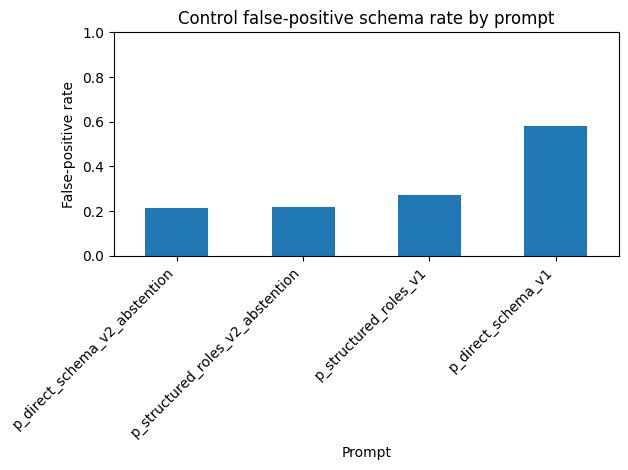

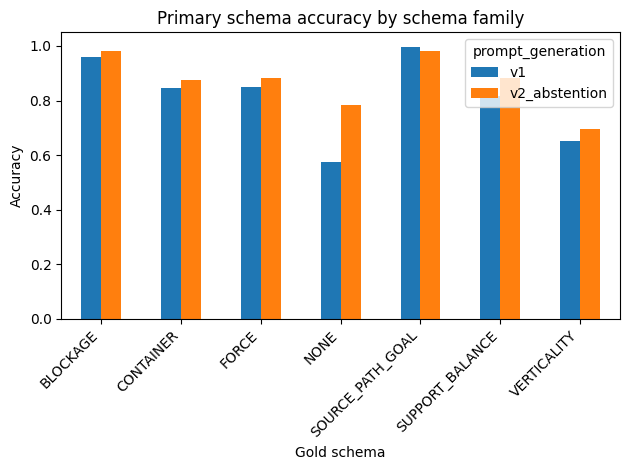

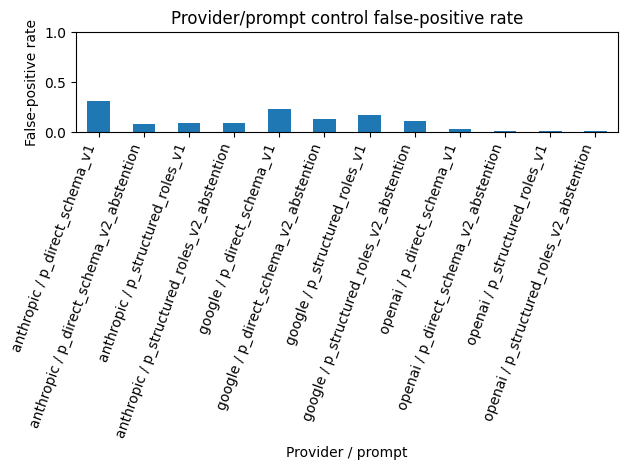

In [14]:
plot_prompt = prompt_metrics.copy().sort_values("control_false_positive_schema_rate")
ax = plot_prompt.plot(kind="bar", x="prompt_id", y="control_false_positive_schema_rate", legend=False)
ax.set_title("Control false-positive schema rate by prompt")
ax.set_xlabel("Prompt")
ax.set_ylabel("False-positive rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plot_control_false_positive_by_prompt.png", dpi=200)
plt.show()

plot_schema = schema_family_metrics.pivot_table(
    index="expected_schema_primary",
    columns="prompt_generation",
    values="primary_schema_accuracy",
    aggfunc="mean"
)
ax = plot_schema.plot(kind="bar")
ax.set_title("Primary schema accuracy by schema family")
ax.set_xlabel("Gold schema")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plot_schema_family_accuracy.png", dpi=200)
plt.show()

plot_provider = provider_conservatism.copy()
plot_provider["label"] = plot_provider["provider"] + " / " + plot_provider["prompt_id"]
ax = plot_provider.plot(kind="bar", x="label", y="control_false_positive_rate", legend=False)
ax.set_title("Provider/prompt control false-positive rate")
ax.set_xlabel("Provider / prompt")
ax.set_ylabel("False-positive rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "plot_provider_control_false_positive.png", dpi=200)
plt.show()

## 14. Interpretation notes for thesis writing

Use the exported tables as follows:

| Thesis purpose | Recommended output |
|---|---|
| Gold dataset exact counts | `gold_dataset_sentence_type_summary.csv`; `gold_dataset_schema_counts.csv` |
| Parse/run summary | `thesis_table_01_run_parse_summary.csv`; `parse_status_counts.csv` |
| Prompt comparison | `thesis_table_02_prompt_comparison.csv`; `headline_prompt_metrics.csv` |
| Macro-F1 / precision / recall | `classification_report_schema_by_prompt.csv`; `classification_report_schema_by_provider.csv` |
| Confusion matrices | `confusion_schema_by_generation_*.csv`; `confusion_schema_by_prompt_*.csv` |
| Abstention and over-attribution | `control_abstention_metrics_by_prompt_provider.csv` |
| v1/v2 paired comparison | `paired_v1_v2_summary_metrics.csv`; `paired_v1_v2_control_change_counts.csv` |
| Temperature/repetition stability | `condition_repetition_stability_summary.csv` |
| Provider conservatism | `provider_conservatism_index_by_prompt.csv` |
| Provider agreement | `provider_agreement_summary_by_prompt_sentence_type.csv` |

When inserting a table into the thesis, cite the source file directly beneath it, for example:

```text
Source: data/outputs/quantitative_statistics/thesis_table_02_prompt_comparison.csv.
```